
## Goal:

###With the same setup as the previous notebook, work on manually writing the **```loss.backward()```** call.


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
names = open('names.txt','r').read().splitlines()
names[:6]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte']

In [ ]:
chars = sorted(list(set(''.join(names))))
itos = {i+1:s for i, s in enumerate(chars)}
itos[0] = '.'

stoi = {s:i for i, s in itos.items()}
stoi

vocab_size = len(stoi)
vocab_size

27

In [ ]:
#build dataset

block_size = 3

def build_dataset(names):
  X = []
  Y = []

  for name in names:
    context = [0] * block_size

    for char in name + '.':
      X.append(context)
      Y.append(stoi[char])
      context = context[1:] + [stoi[char]]


  x = torch.tensor(X)
  y = torch.tensor(Y)
  return x, y

In [ ]:
import random
random.seed(42)
random.shuffle(names)

n1 = int(0.8*len(names))
n2 = int(0.9*len(names))


xTr, yTr = build_dataset(names[:n1])
xVal, yVal = build_dataset(names[n1:n2])
xTe, yTe = build_dataset(names[n2:])

In [ ]:
# utility function to compare the manually calculated gradients with the PyTorch gradients

def cmp(element, dt, tor):
  ex = torch.all(dt == tor.grad).item()
  app = torch.allclose(dt, tor.grad)
  hightol = torch.allclose(dt, tor.grad, atol=1e-2)
  maxdiff = (dt-tor.grad).abs().max().item()

  print(f'{element:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | high tolerance: {str(hightol):5s} | maxdiff: {maxdiff}')

In [ ]:
embed_size = 10
hidden_size = 64

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),            generator=g)

# Layer 1
W1 = torch.randn((block_size*embed_size,  hidden_size), generator=g) * (5/3)/(block_size*embed_size)**0.5
b1 = torch.randn(hidden_size,                        generator=g) * 0.1 # b1 is just for gags, useless because of batch norm

# Layer 2
W2 = torch.randn((hidden_size, vocab_size),          generator=g) * 0.1
b2 = torch.rand(vocab_size,                          generator=g) * 0.1 # massively scaled down instead of zeroed down to avoid masked inaccuracies

bnscale = torch.ones((1, hidden_size))*0.1 + 1.0
bnshift = torch.zeros((1, hidden_size))*0.1

parameters = [C, W1, b1, W2, b2, bnscale, bnshift]

print(f'total number of parametrs: {sum(p.nelement() for p in parameters)}') # number of parameters in total

for p in parameters:
  p.requires_grad = True


total number of parametrs: 4137


### Note: many of the above parameters are initialized in non-standard ways because sometimes initializating with e.g. all zeros could mask an incorrect implementation of the backward pass.

In [ ]:
batch_size = 32

ix = torch.randint(0, xTr.shape[0], (batch_size, ), generator = g)
xb, yb = xTr[ix], yTr[ix]

In [ ]:
xb.shape, yb.shape

(torch.Size([32, 3]), torch.Size([32]))

In [ ]:

xb[0]

tensor([ 9, 18, 22])

In [ ]:
# forward-pass
embed = C[xb]
emb_cat = embed.view(batch_size, -1)

hprev = emb_cat @ W1 + b1                                    # shape: batch_size * hidden size

# Batch Norm layer
# mean
bnmeani = 1/batch_size*hprev.sum(0, keepdim=True)            # shape: 1 * hidden_size

# var -> std
diff = hprev - bnmeani                                       # shape: batch_size * hidden size | # (1, 64) broadcasted row-wise over (32, 64) -> (32, 64)
diffsq = diff**2                                             # shape: batch_size * hidden size
bnvari = 1/(batch_size-1)*diffsq.sum(0, keepdim=True)        # shape: 1 * hidden size          | # Bessel correction to divide by n-1 instead of n
bnvari_inv = (bnvari+1e-5)**-0.5

norm_hpreact = diff * bnvari_inv
hpreact = bnscale * norm_hpreact + bnshift                   # shape: batch_size * hidden size

# non-linear activation
hidden = torch.tanh(hpreact)

# loss calculation
logits = hidden @ W2 + b2                                    # shape: batch_size * vocab size

logits_max = logits.max(1, keepdim=True).values
norm_logits = logits - logits_max

counts = norm_logits.exp()
count_sum = counts.sum(1, keepdim=True)
count_sum_inv = count_sum**-1

probs = counts * count_sum_inv
log_probs = probs.log()

loss = -log_probs[range(batch_size), yb].mean()

In [ ]:
# PyTorch backward-pass
for p in parameters:
  p.grad = None

for ele in [log_probs, probs, count_sum_inv, count_sum, counts,
            norm_logits, logits_max, logits, hidden, hpreact, norm_hpreact,
            bnvari_inv, bnvari, diffsq, diff, bnmeani, hprev, emb_cat, embed]:
  ele.retain_grad()

loss.backward()
loss

tensor(3.4349, grad_fn=<NegBackward0>)

```
# max returns max-values and their indices
torch.randn((1, 27)).max(1, keepdim=True)

output:
torch.return_types.max(
values=tensor([[2.4726]]),
indices=tensor([[1]]))
```


## Exercise 1:
backprop through the whole thing manually, backpropagating through exactly all of the variables as they are defined in the forward pass above, one by one

**```log_probs```**



In [ ]:
log_probs.shape

torch.Size([32, 27])

In [ ]:
log_probs[range(batch_size), yb]

tensor([-3.1422, -3.5310, -2.8220, -3.4660, -4.0813, -3.2812, -3.8750, -4.2727,
        -4.5544, -3.1900, -3.2309, -3.3906, -4.0978, -4.0895, -3.3361, -2.6089,
        -4.3392, -2.7406, -3.4913, -3.3958, -4.3171, -3.5937, -3.1883, -3.8537,
        -3.2295, -4.0978, -3.2735, -1.3222, -3.0750, -2.6892, -3.1481, -3.1932],
       grad_fn=<IndexBackward0>)

In [ ]:
# loss = -1/n * (a+b+c)
# dloss/da = -1/n

In [ ]:
dlogprobs = torch.zeros_like(log_probs)
dlogprobs[range(batch_size), yb] = -1/batch_size

cmp('logprobs', dlogprobs, log_probs)


logprobs        | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0


In [ ]:
dlogprobs.shape # the derivative has to be same shape as the original variable log_probs

torch.Size([32, 27])

**```probs```**

In [ ]:
# prob --> log operation --> log prob

#dloss/dprob = dloss / dlogprob * dlogprob / dprob

#log(prob)
# dlogprob/dprob = 1/prob

In [ ]:
probs.shape

torch.Size([32, 27])

In [ ]:
dprobs = 1/probs * dlogprobs     # 32,27 * 32,27
cmp('probs', dprobs, probs)

probs           | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0


**```dcounts_sum_inv```**

In [ ]:
count_sum_inv.shape

torch.Size([32, 1])

In [ ]:
# probs = counts * count_sum_inv --> multiplicative rule

In [ ]:
counts.shape

torch.Size([32, 27])

In [ ]:
dprobs.shape

torch.Size([32, 27])

In [ ]:
# c = a*b (as tensors)

# a[3 x 3] * b[3 x 1] --> technically 2 operations take place here first) broadcast second) multiplication
# a11*b1 + a12*b1 + a13*b1
# a21*b2 + a22*b2 + a23*b2
# a31*b3 + a32*b3 + a33*b3

# dc/db = (a11 + a12 + a13)

In [ ]:
# // dcounts_sum_inv = counts * dprobs # --> need to convert shape to 32,1

dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
cmp('counts_sum_inv', dcounts_sum_inv, count_sum_inv)

counts_sum_inv  | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0


**```dcounts_sum```**

In [ ]:
count_sum.shape

torch.Size([32, 1])

In [ ]:
# where is count_sum used??
# count_sum_inv = count_sum**-1

In [ ]:
# Tentatively then
# dcounts_sum = (-1/count_sum**2) * dcounts_sum_inv


In [ ]:
# Let's analyze shapes
count_sum_inv.shape, count_sum.shape

(torch.Size([32, 1]), torch.Size([32, 1]))

In [ ]:
dcounts_sum = (-1/count_sum**2) * dcounts_sum_inv # this is ok, but better to have **-2
cmp('counts_sum', dcounts_sum, count_sum)

counts_sum      | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0


**```dcounts_sum```**

In [ ]:
# where is counts used ??
# count_sum = counts.sum(1, keepdim=True)
# probs = counts * count_sum_inv

# so this is a two parter derivative

In [ ]:
# dcounts = (part 1) + (part 2)

# dcounts = [dl/dcount_sum * dcount_sum/dcounts] + [dl/prob * dprob/dcounts]

# part 1 tentative
# dcounts = (1 * dcounts_sum)

# a11 a12 a13 -> b1 =  (a11+a12+a13) -> db/da11 = 1
# a21 a22 a23 -> b2 =  (a21+a22+a23)
# a31 a32 a33 -> b3 =  (a31+a32+a33)


# part 2 tentative
# dcounts += (count_sum_inv * dprobs)

In [ ]:
# Let's analyze shapes
# part 1
print(counts.shape, dcounts_sum.shape) # --> dcounts_sum needs to be replicated across columns

# part 2
print(count_sum_inv.shape, dprobs.shape) # --> this works fine!

torch.Size([32, 27]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 27])


In [ ]:
# part 1
dcounts = torch.ones_like(counts) * (1 * dcounts_sum)
# part 2
dcounts += (count_sum_inv * dprobs)

cmp('counts', dcounts, counts)

counts          | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0


**```dnorm_logits```**

In [ ]:
# where used?
# counts = norm_logits.exp()

In [ ]:
# tentative
# dnorm_logits = counts * dcounts

In [ ]:
# analyze shapes
counts.shape, norm_logits.shape

(torch.Size([32, 27]), torch.Size([32, 27]))

In [ ]:
dnorm_logits = counts * dcounts
cmp('norm_logits', dnorm_logits, norm_logits)

norm_logits     | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0


**```dlogit_maxes```**

Technically subtracting any value from all logits has the same effect. Therefore changing the value being subtracted(in our case max) has no change on the loss. So ideally dlogit_maxes would all be 0!

In [ ]:
# logit_maxes

# where used
# norm_logits = logits - logits_max

In [ ]:
dnorm_logits.shape, logits_max.shape

(torch.Size([32, 27]), torch.Size([32, 1]))

In [ ]:
# logits.max(1, keepdim=True).indices ---> WRONG!!! think in terms of a computation graph

In [ ]:
# norm_logits = logits - logits_max

# c11 c12 c13 = a11 a12 a13 - b1
# c21 c22 c23 = a21 a22 a23 - b2
# c31 c32 c33 = a31 a32 a33 - b3


# c11 = a11 - b1
# c12 = a12 - b1
# c13 = a13 - b1

# dc/db = -1 accumulates over all c's

In [ ]:
dlogit_maxes = (-1 * dnorm_logits).sum(1, keepdim=True)
cmp('logit_maxes', dlogit_maxes, logits_max)

logit_maxes     | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0


In [ ]:
dlogit_maxes

tensor([[ 2.3283e-09],
        [-2.5611e-09],
        [ 6.9849e-10],
        [ 1.3970e-09],
        [ 3.7253e-09],
        [-2.0955e-09],
        [-4.6566e-09],
        [ 9.3132e-10],
        [-3.2596e-09],
        [-2.0955e-09],
        [ 4.6566e-09],
        [-4.6566e-09],
        [ 6.5193e-09],
        [-2.0955e-09],
        [-3.2596e-09],
        [-3.0268e-09],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 1.8626e-09],
        [ 2.7940e-09],
        [-4.6566e-10],
        [ 0.0000e+00],
        [ 1.3970e-09],
        [-4.1910e-09],
        [-5.5879e-09],
        [ 6.5193e-09],
        [ 4.6566e-10],
        [-1.3970e-09],
        [-2.0955e-09],
        [-7.4506e-09],
        [-2.3283e-10],
        [ 4.6566e-10]], grad_fn=<SumBackward1>)

**```dlogits```**

In [ ]:
# where used
# logits_max = logits.max(1, keepdim=True).values
# norm_logits = logits - logits_max

In [ ]:
logits.shape

torch.Size([32, 27])

In [ ]:
# logits_max = logits.max(

# 1 for max indices and 0 for others
# so we do need to index into the logit_max derivatives now

In [ ]:
# part 1 + part 2
# part 1 tentative
dlogits = torch.zeros_like(logits)
dlogits[range(32), logits.max(1).indices] = 1 * dlogit_maxes

RuntimeError: shape mismatch: value tensor of shape [32, 1] cannot be broadcast to indexing result of shape [32]

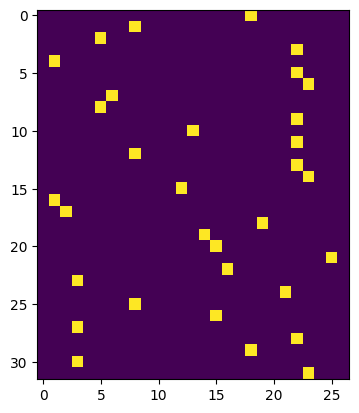

In [ ]:
plt.imshow(F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]))

In [ ]:
# part 1 + part 2
# part 1
dlogits = F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes

# # part 2
dlogits += dnorm_logits.clone()

cmp('logits', dlogits, logits)

logits          | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0


**```h```** hidden

In [ ]:
# usage
# logits = hidden @ W2 + b2

In [ ]:
hidden.shape, W2.shape, logits.shape

(torch.Size([32, 64]), torch.Size([64, 27]), torch.Size([32, 27]))

In [ ]:
# [32 x 64] [64 x 27] - 32, 27 27, 64
#  [2 x 3] [3 x 4] 2,4

# c = a @ b

# a11 a12 a13
# a21 a22 a23

# b11 b12 b13 b14
# b21 b22 b23 b24
# b31 b32 b33 b34

# c11 c12 c13 c14 = a11*b11 + a12*b21 + a13*b31
# c21 c22 c23 c24 =

# dc/da = sum(a row of b) * corresponding row elements of c


In [ ]:
# Transpose of b

# b11 b21 b31
# b12 b22 b32
# b13 b23 b33
# b14 b24 b34

#Regular c

# c11 c12 c13 c14
# c21 c22 c23 c24

In [ ]:
W2.sum(1).unsqueeze(0).shape

torch.Size([1, 64])

In [ ]:
W2.shape ,W2.T.shape, dlogits.shape

(torch.Size([64, 27]), torch.Size([27, 64]), torch.Size([32, 27]))

In [ ]:
dhidden = dlogits @ W2.T
cmp('h', dhidden, hidden)

h               | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0


**```W2```**

In [ ]:
# usage
# logits = hidden @ W2 + b2

In [ ]:
dW2 = hidden.T @ dlogits
cmp('W2', dW2, W2)

W2              | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0


**```b2```**

In [ ]:
# usage
# logits = hidden @ W2 + b2

In [ ]:
b2.shape,  logits.shape

(torch.Size([27]), torch.Size([32, 27]))

In [ ]:
db2 = dlogits.sum(0)
cmp('b2', db2, b2)

b2              | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0


**```hpreact```**

In [ ]:
# usage
# hidden = torch.tanh(hpreact)

In [ ]:
dhpreact = (1-torch.tanh(hpreact)**2)*dhidden
cmp('hpreact', dhpreact, hpreact)


hpreact         | exact: False | approximate: True  | high tolerance: True  | maxdiff: 4.656612873077393e-10


In [ ]:
hpreact.grad

tensor([[-9.6595e-05,  1.1295e-03, -8.8993e-04,  ..., -4.3530e-04,
         -7.5933e-04, -3.6608e-03],
        [-3.0039e-04,  5.0816e-04,  1.5328e-03,  ...,  6.2857e-04,
         -4.0967e-03,  1.4231e-03],
        [-3.1060e-03, -5.6574e-05, -7.8581e-04,  ...,  7.6882e-04,
          1.1635e-03,  5.0934e-03],
        ...,
        [-2.1020e-03,  7.1958e-04, -1.1820e-03,  ...,  7.5550e-04,
         -1.8324e-03, -7.0369e-04],
        [ 2.2079e-03, -2.6519e-03,  1.5284e-04,  ...,  2.8953e-04,
          2.4637e-03,  6.4061e-04],
        [-8.4296e-04,  3.2988e-04, -4.4264e-03,  ...,  6.7705e-04,
          2.4411e-03,  2.5571e-03]])

In [ ]:
dhpreact

tensor([[-9.6595e-05,  1.1295e-03, -8.8993e-04,  ..., -4.3530e-04,
         -7.5933e-04, -3.6608e-03],
        [-3.0039e-04,  5.0816e-04,  1.5328e-03,  ...,  6.2857e-04,
         -4.0967e-03,  1.4231e-03],
        [-3.1060e-03, -5.6574e-05, -7.8581e-04,  ...,  7.6882e-04,
          1.1635e-03,  5.0934e-03],
        ...,
        [-2.1020e-03,  7.1958e-04, -1.1820e-03,  ...,  7.5550e-04,
         -1.8324e-03, -7.0369e-04],
        [ 2.2079e-03, -2.6519e-03,  1.5284e-04,  ...,  2.8953e-04,
          2.4637e-03,  6.4061e-04],
        [-8.4296e-04,  3.2988e-04, -4.4264e-03,  ...,  6.7705e-04,
          2.4411e-03,  2.5571e-03]], grad_fn=<MulBackward0>)

In [ ]:
x, y = torch.where(dhpreact != hpreact.grad)

In [ ]:
dhpreact[0,0].item()

-9.659531497163698e-05

In [ ]:
hpreact.grad[0,0].item() # NOT SURE WHERE THE PRECISION DIFFERS??

-9.659530769567937e-05

In [ ]:
hidden.shape, hpreact.shape

(torch.Size([32, 64]), torch.Size([32, 64]))

**```bnscale```**

In [ ]:
# usage
# hpreact = bnscale * norm_hpreact + bnshift                   # shape: batch_size * hidden size

hpreact.shape, bnscale.shape, norm_hpreact.shape

# bnscale replicated across hpreact's row, so sum up the rows to get bnscale derivative

(torch.Size([32, 64]), torch.Size([1, 64]), torch.Size([32, 64]))

In [ ]:


dbnscale = (norm_hpreact * dhpreact).sum(0, keepdim=True)
cmp('bnscale', dbnscale, bnscale)

bnscale         | exact: False | approximate: True  | high tolerance: True  | maxdiff: 1.862645149230957e-09


**```bnshift```**

In [ ]:
# usage
# hpreact = bnscale * norm_hpreact + bnshift                   # shape: batch_size * hidden size

dbnshift = dhpreact.sum(0, keepdim=True)
cmp('bnshift', dbnshift, bnshift)

bnshift         | exact: False | approximate: True  | high tolerance: True  | maxdiff: 3.725290298461914e-09


**```norm_hpreact```**

In [ ]:
# usage
# hpreact = bnscale * norm_hpreact + bnshift                   # shape: batch_size * hidden size

bnscale.shape, hpreact.shape, norm_hpreact.shape

(torch.Size([1, 64]), torch.Size([32, 64]), torch.Size([32, 64]))

In [ ]:
dnorm_hpreact = bnscale * dhpreact
cmp('norm_hpreact', dnorm_hpreact, norm_hpreact)

norm_hpreact    | exact: False | approximate: True  | high tolerance: True  | maxdiff: 6.984919309616089e-10


**```bnvari_inv```**

In [ ]:
# usage
# norm_hpreact = diff * bnvari_inv
bnvari_inv.shape, norm_hpreact.shape, diff.shape

(torch.Size([1, 64]), torch.Size([32, 64]), torch.Size([32, 64]))

In [ ]:
dbnvari_inv = (diff * dnorm_hpreact).sum(0, keepdim=True)
cmp('bnvari_inv', dbnvari_inv, bnvari_inv)


bnvari_inv      | exact: False | approximate: True  | high tolerance: True  | maxdiff: 7.450580596923828e-09


**```bnvari```**

In [ ]:
# usage
# bnvari_inv = (bnvari+1e-5)**-0.5

In [ ]:
dbnvari = -0.5 * (bnvari+1e-5)**-1.5 * dbnvari_inv
cmp('bnvari', dbnvari, bnvari)

bnvari          | exact: False | approximate: True  | high tolerance: True  | maxdiff: 9.313225746154785e-10


**```diffsq```**

In [ ]:
# usage

# bnvari = 1/(batch_size-1)*diffsq.sum(0, keepdim=True)

diffsq.shape, bnvari.shape

(torch.Size([32, 64]), torch.Size([1, 64]))

In [ ]:
ddiffsq = torch.ones_like(diffsq) * 1/(batch_size-1) * dbnvari

cmp('diffsq', ddiffsq, diffsq)


diffsq          | exact: False | approximate: True  | high tolerance: True  | maxdiff: 2.9103830456733704e-11


**```diff```**

In [ ]:
# usage
# two parter
# norm_hpreact = diff * bnvari_inv
# diffsq = diff**2

diff.shape, norm_hpreact.shape, bnvari_inv.shape, ddiffsq.shape

(torch.Size([32, 64]),
 torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]))

In [ ]:
# part 1

ddiff = bnvari_inv * dnorm_hpreact
ddiff += 2 * diff * ddiffsq
cmp('diff', ddiff, diff)


diff            | exact: False | approximate: True  | high tolerance: True  | maxdiff: 6.984919309616089e-10


**```bnmeani```**


In [ ]:
# usage
# diff = hprev - bnmeani
bnmeani.shape, diff.shape

(torch.Size([1, 64]), torch.Size([32, 64]))

In [ ]:
dbnmeani = -1.0 * ddiff.sum(0, keepdim=True)
cmp('bnmeani', dbnmeani, bnmeani)


bnmeani         | exact: False | approximate: True  | high tolerance: True  | maxdiff: 3.725290298461914e-09


**```hprebn```**

In [ ]:
# usage
# diff = hprev - bnmeani
# bnmeani = 1/batch_size*hprev.sum(0, keepdim=True)            # shape: 1 * hidden_size

# two parter
hprev.shape, diff.shape, bnmeani.shape

(torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([1, 64]))

In [ ]:
dhprev = ddiff.clone()

dhprev += torch.ones_like(hprev) * 1/batch_size * dbnmeani

cmp('hprev', dhprev, hprev)

hprev           | exact: False | approximate: True  | high tolerance: True  | maxdiff: 6.984919309616089e-10


In [ ]:
hprev.grad[0,0].item()

-0.0001342624018434435

In [ ]:
ddiff[0,0].item()

-9.334996138932183e-05

In [ ]:
torch.allclose(dhprev, hprev.grad, atol=1e-2)

True

**```emb_cat```**

In [ ]:
# usage
# hprev = emb_cat @ W1 + b1
emb_cat.shape, hprev.shape, W1.shape

(torch.Size([32, 30]), torch.Size([32, 64]), torch.Size([30, 64]))

In [ ]:
demb_cat = dhprev @ W1.T
cmp('emb_cat', demb_cat, emb_cat)


emb_cat         | exact: False | approximate: True  | high tolerance: True  | maxdiff: 1.862645149230957e-09


**```W1```**
**```b1```**

In [ ]:
# usage
# hprev = emb_cat @ W1 + b1                                    # shape: batch_size * hidden size

dW1 = emb_cat.T @ dhprev
db1 = dhprev.sum(0, keepdim=True) # original b1 is of shape (200) but db1 has keepdim = True, remove for correct comparison
cmp('W1', dW1, W1)
cmp('b1', db1, b1)

W1              | exact: False | approximate: True  | high tolerance: True  | maxdiff: 5.587935447692871e-09
b1              | exact: False | approximate: True  | high tolerance: True  | maxdiff: 4.190951585769653e-09


In [ ]:
torch.ones(200).shape, torch.ones((1,200)).shape

(torch.Size([200]), torch.Size([1, 200]))

In [ ]:
torch.allclose(torch.ones(200), torch.ones((1,200)))

True

**```embed```**

**```C```**



In [ ]:
# usage
# embed = C[xb]
# emb_cat = embed.view(batch_size, -1)

emb_cat.shape, embed.shape, C.shape, xb.shape

(torch.Size([32, 30]),
 torch.Size([32, 3, 10]),
 torch.Size([27, 10]),
 torch.Size([32, 3]))

In [ ]:
# iterC = embed.view(-1, embed_size)
# iterC[0]

In [ ]:
xb[0]

tensor([ 9, 18, 22])

In [ ]:
dembed = demb_cat.view(embed.shape)
cmp('embed', dembed, embed)

dC = torch.zeros_like(C)

for i, example in enumerate(xb):
  for j, letter in enumerate(example):
    dC[letter] += dembed[i, j]

cmp('C', dC, C)

embed           | exact: False | approximate: True  | high tolerance: True  | maxdiff: 1.862645149230957e-09
C               | exact: False | approximate: True  | high tolerance: True  | maxdiff: 4.6566128730773926e-09


Alternate implementation (vectorized)

In [ ]:
F.one_hot(xb.flatten(), num_classes=27).float().permute(1, 0).shape

torch.Size([27, 96])

In [ ]:
dembed.view((-1, embed_size)).shape

torch.Size([96, 10])

## ALL TOGETHER

In [ ]:
# Exercise 1: backprop through the whole thing manually,
# backpropagating through exactly all of the variables
# as they are defined in the forward pass above, one by one

dlogprobs = torch.zeros_like(log_probs)
dlogprobs[range(batch_size), yb] = -1.0/batch_size

dprobs = 1.0* probs**-1 * dlogprobs     # 32,27 * 32,27
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
dcounts_sum = (-1.0*count_sum**-2.0) * dcounts_sum_inv # this is ok, but better to have **-2

# part 1
dcounts = torch.ones_like(counts) * (1.0 * dcounts_sum)
# part 2
dcounts += (count_sum_inv * dprobs)

dnorm_logits = counts * dcounts
dlogit_maxes = (-1.0 * dnorm_logits).sum(1, keepdim=True)

# part 1 + part 2
# part 1
dlogits = F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
# # part 2
dlogits += dnorm_logits.clone()

dhidden = dlogits @ W2.T
dW2 = hidden.T @ dlogits
db2 = dlogits.sum(0)

dhpreact = (1.0-hidden**2.0)*dhidden
dbnscale = (norm_hpreact * dhpreact).sum(0, keepdim=True)
dbnshift = dhpreact.sum(0, keepdim=True)

dnorm_hpreact = bnscale * dhpreact

dbnvari_inv = (diff * dnorm_hpreact).sum(0, keepdim=True)
dbnvari = -0.5 * (bnvari+1e-5)**-1.5 * dbnvari_inv

ddiffsq = torch.ones_like(diffsq) * 1/(batch_size-1) * dbnvari
ddiff = bnvari_inv * dnorm_hpreact
ddiff += 2 * diff * ddiffsq
dbnmeani = -1.0 * ddiff.sum(0, keepdim=True)

dhprev = ddiff.clone()
dhprev += torch.ones_like(hprev) * 1/batch_size * dbnmeani


demb_cat = dhprev @ W1.T
dW1 = emb_cat.T @ dhprev
db1 = dhprev.sum(0, keepdim=True)

dembed = demb_cat.view(embed.shape)

# MORE INTUITIVE WITH FOR LOOPS

# dC = torch.zeros_like(C)

# for i, example in enumerate(xb):
#   for j, letter in enumerate(example):
#     dC[letter] += dembed[i, j]

##

# VECTORIZED !!!

Xe = F.one_hot(xb.flatten(), num_classes=27).float().permute(1, 0)
dC = Xe @ dembed.view((-1, embed_size))

##


cmp('logprobs', dlogprobs, log_probs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, count_sum_inv)
cmp('counts_sum', dcounts_sum, count_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logits_max)
cmp('logits', dlogits, logits)
cmp('h', dhidden, hidden)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bnscale', dbnscale, bnscale)
cmp('bnshift', dbnshift, bnshift)
cmp('norm_hpreact', dnorm_hpreact, norm_hpreact)
cmp('bnvari_inv', dbnvari_inv, bnvari_inv)
cmp('bnvari', dbnvari, bnvari)
cmp('diffsq', ddiffsq, diffsq)
cmp('diff', ddiff, diff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprev', dhprev, hprev)
cmp('emb_cat', demb_cat, emb_cat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('embed', dembed, embed)
cmp('C', dC, C)


logprobs        | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | high tolerance: True  | maxdiff: 0.0

# EXERCISE 2

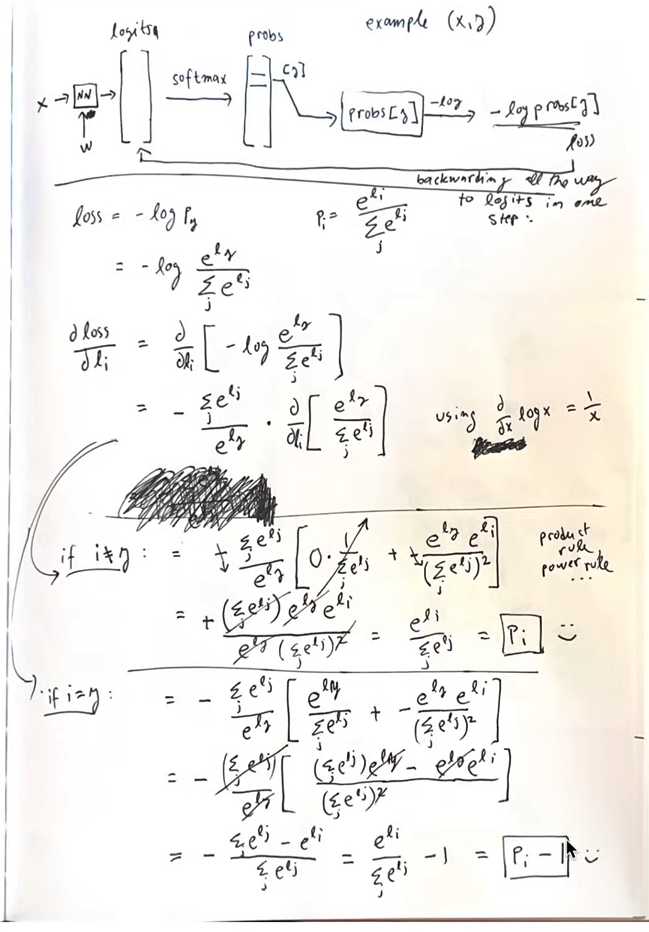

In [ ]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.4349286556243896 diff: 0.0


In [ ]:
logits.shape

torch.Size([32, 27])

In [ ]:
# backward pass

# -----------------
# YOUR CODE HERE :)
dlogits = F.softmax(logits,dim=1)
dlogits[range(batch_size), yb] -= 1
dlogits /= batch_size

# -----------------

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | high tolerance: True  | maxdiff: 7.2177499532699585e-09


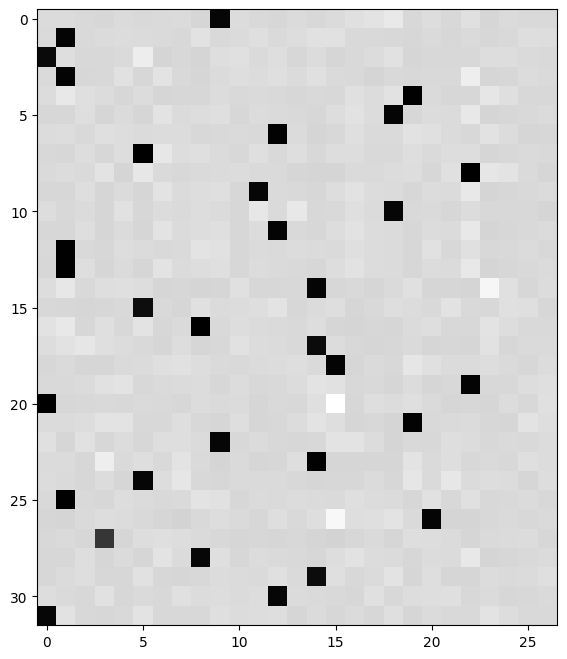

In [ ]:
plt.figure(figsize= (8,8))
plt.imshow(dlogits.detach(), cmap="gray")

In [ ]:
F.softmax(logits,dim=1)[0]

tensor([0.0375, 0.0364, 0.0303, 0.0174, 0.0360, 0.0283, 0.0309, 0.0374, 0.0141,
        0.0432, 0.0411, 0.0272, 0.0179, 0.0381, 0.0240, 0.0371, 0.0597, 0.0793,
        0.1038, 0.0238, 0.0472, 0.0216, 0.0599, 0.0137, 0.0389, 0.0259, 0.0294],
       grad_fn=<SelectBackward0>)

In [ ]:
dlogits[0] * batch_size # --> index 9 has a negative gradient, so during weight update the prob against that index will be increased (-lr)*neg_gradient

tensor([ 0.0375,  0.0364,  0.0303,  0.0174,  0.0360,  0.0283,  0.0309,  0.0374,
         0.0141, -0.9568,  0.0411,  0.0272,  0.0179,  0.0381,  0.0240,  0.0371,
         0.0597,  0.0793,  0.1038,  0.0238,  0.0472,  0.0216,  0.0599,  0.0137,
         0.0389,  0.0259,  0.0294], grad_fn=<MulBackward0>)

# Analogy

A neural net is like a pulley system, where the tension across the system needs to be maintained while making the pulley system as "likely" as possible (given our dataset). In doing so, the neurons(levers) that are the valid labels are pulled up in terms of their probability, while other neurons are squashed - all while maintaining "tension" (should I think of this as equivalent to regularization??)

# Exercise 3

In [ ]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# BatchNorm paper: https://arxiv.org/abs/1502.03167

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bnscale * (hprev - hprev.mean(0, keepdim=True)) / torch.sqrt(hprev.var(0, keepdim=True, unbiased=True) + 1e-5) + bnshift
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


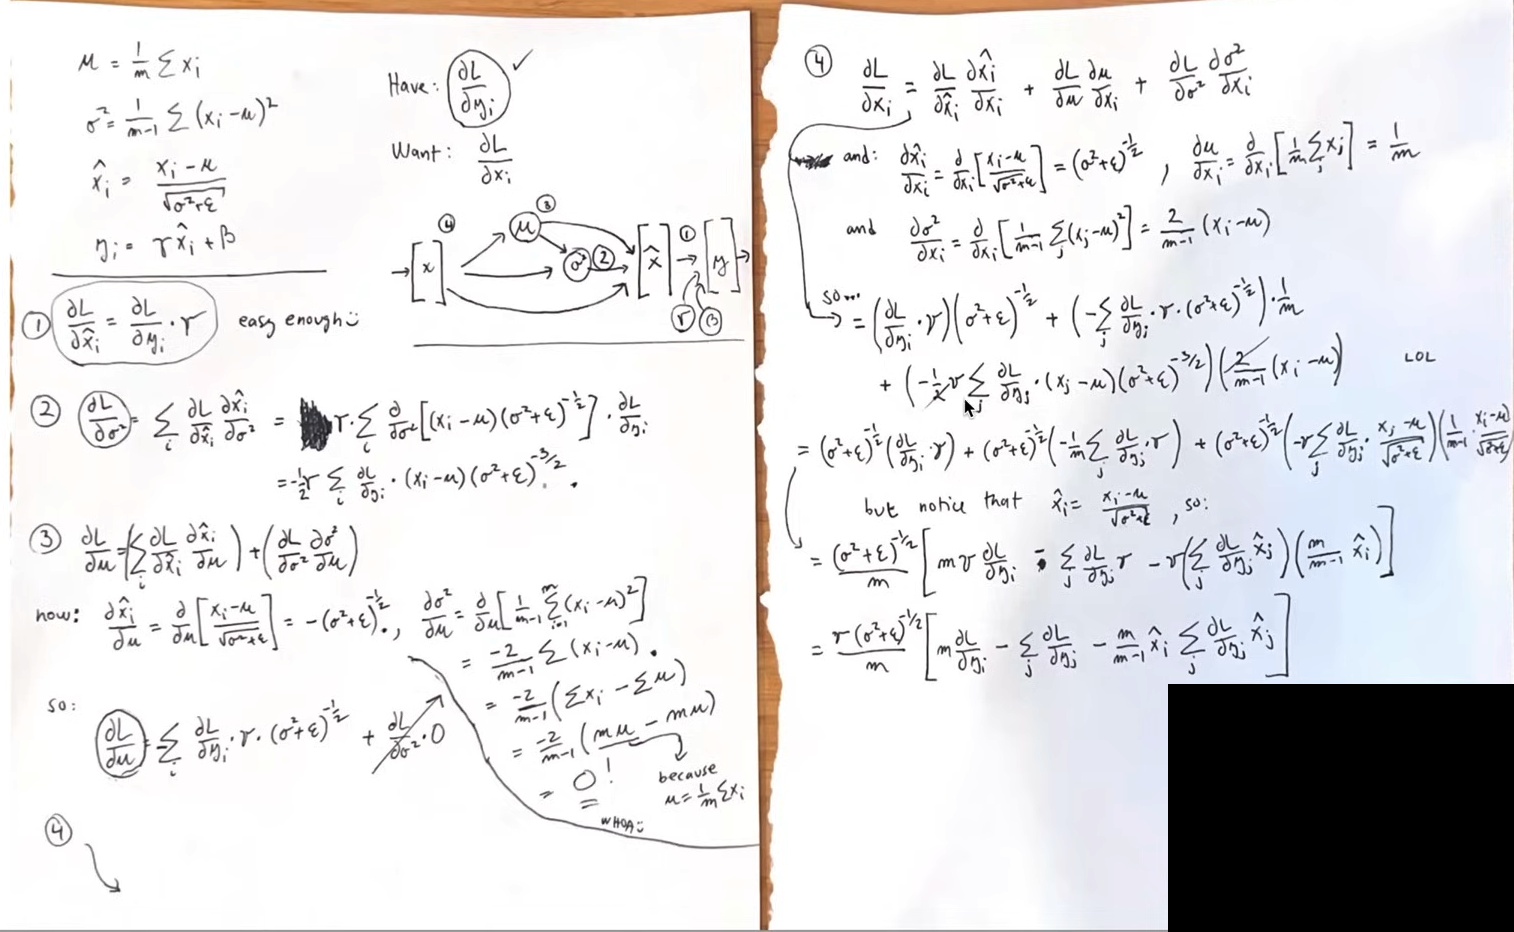

In [ ]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# -----------------
# YOUR CODE HERE :)
# Andrej
dhprev = bnscale*bnvari_inv/batch_size * (batch_size*dhpreact - dhpreact.sum(0) - batch_size/(batch_size-1)*norm_hpreact*(dhpreact*norm_hpreact).sum(0))
# -----------------

cmp('hprebn', dhprev, hprev) # I can only get approximate to be true, my maxdiff is 9e-10
# -----------------



hprebn          | exact: False | approximate: True  | high tolerance: True  | maxdiff: 9.313225746154785e-10


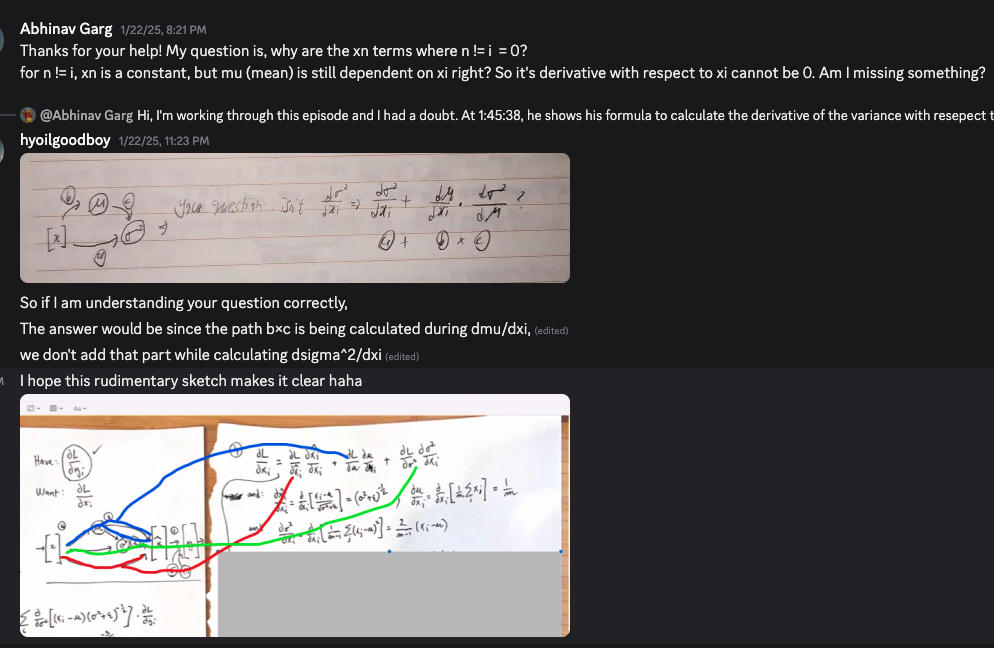


https://discord.com/channels/1020383067459821711/1029850066917265538/1332726895984513024

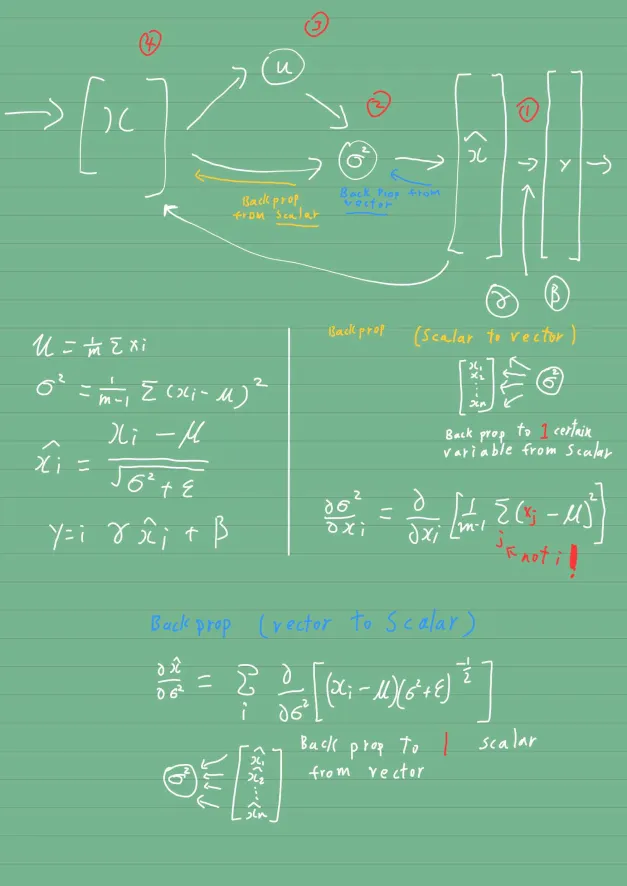

In [ ]:
# ALL THE INCORRECT IMPLEMENTATIONS I MADE

# OPTION A
t = ( hpreact_fast - bnshift ) / bnscale
# dhprev = dhpreact * ((bnscale / torch.sqrt(hprev.var(0, keepdim=True, unbiased=True) + 1e-5)) * ((batch_size-1)/batch_size) * (1-t**2))
dhprev = dhpreact * (bnscale / (batch_size * torch.sqrt(hprev.var(0, keepdim=True, unbiased=True) + 1e-5))) * ((batch_size-1)-t**2)

# OPTION B
t = ( hpreact_fast - bnshift ) / bnscale
# dhprev = dhpreact * ((bnscale / torch.sqrt(hprev.var(0, keepdim=True, unbiased=True) + 1e-5)) * ((batch_size-1)/batch_size) * (1-t**2))
dhprev = dhpreact * (bnscale / (batch_size * torch.sqrt(hprev.var(0, keepdim=True, unbiased=True) + 1e-5))) * ((batch_size-1)-t**2)

# OPTION C
dhprev = bnscale * bnvari_inv/batch_size * (batch_size * dhpreact + (batch_size/(1-batch_size)) * norm_hpreact * (dhpreact*norm_hpreact).sum(0))

# OPTION D
g = (hprev - hprev.mean(0, keepdim=True)) / torch.sqrt(hprev.var(0, keepdim=True, unbiased=True) + 1e-5)

a = (1-batch_size**-1)
b = 1/(batch_size*(batch_size-1))

c = (g**2)

# OPTION E
dhprev = bnscale/torch.sqrt(hprev.var(0, keepdim=True, unbiased=True) + 1e-5) * (a - b*c)

# OPTION F
dhprev = bnscale*bnvari_inv/batch_size * (- dhpreact.sum(0) - norm_hpreact*(dhpreact*norm_hpreact).sum(0) + dhpreact*(batch_size-1-norm_hpreact**2/batch_size))

# OPTION G
dhprev = bnscale*bnvari_inv/batch_size * (- dhpreact.sum(0) + (batch_size-1)*dhpreact)

# -----------------

cmp('hprebn', dhprev, hprev) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: False | high tolerance: True  | maxdiff: 0.0017321724444627762


# Exercise 4

In [ ]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
embed_size = 10 # the dimensionality of the character embedding vectors
hidden_size = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, embed_size),            generator=g)

# Layer 1
W1 = torch.randn((block_size*embed_size,  hidden_size), generator=g) * (5/3)/(block_size*embed_size)**0.5
b1 = torch.randn(hidden_size,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((hidden_size, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bnscale = torch.randn((1, hidden_size))*0.1 + 1.0
bnshift = torch.randn((1, hidden_size))*0.1

parameters = [C, W1, b1, W2, b2, bnscale, bnshift]
print(f'total number of parametrs: {sum(p.nelement() for p in parameters)}') # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []


total number of parametrs: 12297


In [ ]:
# use this context manager for efficiency once your backward pass is written (TODO)
#with torch.no_grad():

# kick off optimization
for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, xTr.shape[0], (batch_size,), generator=g)
  xb, yb = xTr[ix], yTr[ix] # batch X,Y

  # --------------------------------------------------------------------------------------------------------------------------
  # FORWARD PASS
  embed = C[xb] # embed the characters into vectors
  emb_cat = embed.view(embed.shape[0], -1) # concatenate the vectors
  # Linear layer
  hprev = emb_cat @ W1 + b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hprev.mean(0, keepdim=True)
  bnvari = hprev.var(0, keepdim=True, unbiased=True)
  bnvari_inv = (bnvari + 1e-5)**-0.5
  norm_hpreact = (hprev - bnmeani) * bnvari_inv
  hpreact = bnscale * norm_hpreact + bnshift
  # -------------------------------------------------------------
  # Non-linearity
  hidden = torch.tanh(hpreact) # hidden layer
  logits = hidden @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, yb) # loss function


  # --------------------------------------------------------------------------------------------------------------------------

  # BACKWARD PASS
  for p in parameters:
    p.grad = None
  loss.backward() # use this for correctness comparisons, delete it later!

  # MANUAL BACKPROP! #swole_doge_meme
  # --------------------------------------------------------------------
  dC, dW1, db1, dW2, db2, dbnscale, dbnshift = None, None, None, None, None, None, None



  dlogits = F.softmax(logits,dim=1)
  dlogits[range(batch_size), yb] -= 1
  dlogits /= batch_size

  # output linear layer
  dhidden = dlogits @ W2.T
  dW2 = hidden.T @ dlogits
  db2 = dlogits.sum(0)

  # non-linearity
  dhpreact = (1.0-hidden**2.0)*dhidden

  # batchnorm
  dbnscale = (norm_hpreact * dhpreact).sum(0, keepdim=True)
  dbnshift = dhpreact.sum(0, keepdim=True)
  dhprev = bnscale*bnvari_inv/batch_size * (batch_size*dhpreact - dhpreact.sum(0) - batch_size/(batch_size-1)*norm_hpreact*(dhpreact*norm_hpreact).sum(0))

  # 1st linear layer
  demb_cat = dhprev @ W1.T
  dW1 = emb_cat.T @ dhprev
  db1 = dhprev.sum(0, keepdim=True)

  # encoding layer
  dembed = demb_cat.view(embed.shape)

  Xe = F.one_hot(xb.flatten(), num_classes=27).float().permute(1, 0)
  dC = Xe @ dembed.view((-1, embed_size))

  grads = [dC, dW1, db1, dW2, db2, dbnscale, dbnshift]
  # -----------------

  # --------------------------------------------------------------------------------------------------------------------------

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p, grad in zip(parameters, grads):
    p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
    #p.data += -lr * grad # new way of swole doge TODO: enable

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  # if i >= 100: # TODO: delete early breaking when you're ready to train the full net
  #   break

      0/ 200000: 2.5913
  10000/ 200000: 2.1614
  20000/ 200000: 2.0483
  30000/ 200000: 2.1520
  40000/ 200000: 1.9249
  50000/ 200000: 2.1140
  60000/ 200000: 2.2873
  70000/ 200000: 2.6553
  80000/ 200000: 2.0454
  90000/ 200000: 2.5565
 100000/ 200000: 2.2873
 110000/ 200000: 1.9872
 120000/ 200000: 1.9073
 130000/ 200000: 1.7841
 140000/ 200000: 1.8908
 150000/ 200000: 2.0611
 160000/ 200000: 2.1365
 170000/ 200000: 2.0239
 180000/ 200000: 2.1195
 190000/ 200000: 2.2951


In [ ]:
# useful for checking your gradients
for p,g in zip(parameters, grads):
  cmp(str(tuple(p.shape)), g, p)

(27, 10)        | exact: False | approximate: True  | high tolerance: True  | maxdiff: 5.029141902923584e-08
(30, 200)       | exact: False | approximate: True  | high tolerance: True  | maxdiff: 1.1175870895385742e-08
(200,)          | exact: False | approximate: True  | high tolerance: True  | maxdiff: 9.313225746154785e-09
(200, 27)       | exact: False | approximate: True  | high tolerance: True  | maxdiff: 1.4901161193847656e-08
(27,)           | exact: False | approximate: True  | high tolerance: True  | maxdiff: 7.450580596923828e-09
(1, 200)        | exact: False | approximate: True  | high tolerance: True  | maxdiff: 5.587935447692871e-09
(1, 200)        | exact: False | approximate: True  | high tolerance: True  | maxdiff: 1.1175870895385742e-08


In [ ]:
# calibrate the batch norm at the end of training
with torch.no_grad():
  # pass the training set through
  embed = C[xTr]
  emb_cat = embed.view(embed.shape[0], -1)
  hpreact = emb_cat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmeani = hpreact.mean(0, keepdim=True)
  bnvari = hpreact.var(0, keepdim=True, unbiased=True)

In [ ]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (xTr, yTr),
    'val': (xVal, yVal),
    'test': (xTe, yTe),
  }[split]
  embed = C[x] # (N, block_size, n_embd)
  emb_cat = embed.view(embed.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = emb_cat @ W1 + b1
  hpreact = bnscale * (hpreact - bnmeani) * (bnvari + 1e-5)**-0.5 + bnshift
  hidden = torch.tanh(hpreact) # (N, n_hidden)
  logits = hidden @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.070624828338623
val 2.112419366836548


In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bnscale * (hpreact - bnmeani) * (bnvari + 1e-5)**-0.5 + bnshift
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmahzah.
jhavifi.
mri.
reh.
caskanden.
jazhita.
deliah.
jareen.
nellara.
chaiivon.
leigh.
ham.
join.
quinn.
shoilea.
jadilyn.
jero.
dearyn.
kai.
eveirsan.


# WITH NO GRAD - RELYING SOLELY ON MANUAL IMPLEMENTATION

In [ ]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
embed_size = 10 # the dimensionality of the character embedding vectors
hidden_size = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, embed_size),            generator=g)

# Layer 1
W1 = torch.randn((block_size*embed_size,  hidden_size), generator=g) * (5/3)/(block_size*embed_size)**0.5
b1 = torch.randn(hidden_size,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((hidden_size, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bnscale = torch.randn((1, hidden_size))*0.1 + 1.0
bnshift = torch.randn((1, hidden_size))*0.1

parameters = [C, W1, b1, W2, b2, bnscale, bnshift]
print(f'total number of parametrs: {sum(p.nelement() for p in parameters)}') # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []


total number of parametrs: 12297


In [ ]:
# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():

  # kick off optimization
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, xTr.shape[0], (batch_size,), generator=g)
    xb, yb = xTr[ix], yTr[ix] # batch X,Y

    # --------------------------------------------------------------------------------------------------------------------------
    # FORWARD PASS
    embed = C[xb] # embed the characters into vectors
    emb_cat = embed.view(embed.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprev = emb_cat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmeani = hprev.mean(0, keepdim=True)
    bnvari = hprev.var(0, keepdim=True, unbiased=True)
    bnvari_inv = (bnvari + 1e-5)**-0.5
    norm_hpreact = (hprev - bnmeani) * bnvari_inv
    hpreact = bnscale * norm_hpreact + bnshift
    # -------------------------------------------------------------
    # Non-linearity
    hidden = torch.tanh(hpreact) # hidden layer
    logits = hidden @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, yb) # loss function


    # --------------------------------------------------------------------------------------------------------------------------

    # BACKWARD PASS
    for p in parameters:
      p.grad = None

    # NO loss.backward

    # MANUAL BACKPROP! #swole_doge_meme
    # --------------------------------------------------------------------
    dC, dW1, db1, dW2, db2, dbnscale, dbnshift = None, None, None, None, None, None, None



    dlogits = F.softmax(logits,dim=1)
    dlogits[range(batch_size), yb] -= 1
    dlogits /= batch_size

    # output linear layer
    dhidden = dlogits @ W2.T
    dW2 = hidden.T @ dlogits
    db2 = dlogits.sum(0)

    # non-linearity
    dhpreact = (1.0-hidden**2.0)*dhidden

    # batchnorm
    dbnscale = (norm_hpreact * dhpreact).sum(0, keepdim=True)
    dbnshift = dhpreact.sum(0, keepdim=True)
    dhprev = bnscale*bnvari_inv/batch_size * (batch_size*dhpreact - dhpreact.sum(0) - batch_size/(batch_size-1)*norm_hpreact*(dhpreact*norm_hpreact).sum(0))

    # 1st linear layer
    demb_cat = dhprev @ W1.T
    dW1 = emb_cat.T @ dhprev
    # db1 = dhprev.sum(0, keepdim=True)
    db1 = dhprev.sum(0) # no keepdims


    # encoding layer
    dembed = demb_cat.view(embed.shape)

    Xe = F.one_hot(xb.flatten(), num_classes=27).float().permute(1, 0)
    dC = Xe @ dembed.view((-1, embed_size))

    grads = [dC, dW1, db1, dW2, db2, dbnscale, dbnshift]
    # -----------------

    # --------------------------------------------------------------------------------------------------------------------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      # p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/ 200000: 3.7888
  10000/ 200000: 2.1659
  20000/ 200000: 2.3510
  30000/ 200000: 2.4086
  40000/ 200000: 1.9188
  50000/ 200000: 2.3059
  60000/ 200000: 2.3952
  70000/ 200000: 2.0977
  80000/ 200000: 2.3277
  90000/ 200000: 2.1335
 100000/ 200000: 1.9498
 110000/ 200000: 2.2573
 120000/ 200000: 2.0085
 130000/ 200000: 2.4419
 140000/ 200000: 2.3632
 150000/ 200000: 2.0884
 160000/ 200000: 2.0245
 170000/ 200000: 1.8804
 180000/ 200000: 2.0238
 190000/ 200000: 1.9218


In [ ]:
# calibrate the batch norm at the end of training
with torch.no_grad():
  # pass the training set through
  embed = C[xTr]
  emb_cat = embed.view(embed.shape[0], -1)
  hpreact = emb_cat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmeani = hpreact.mean(0, keepdim=True)
  bnvari = hpreact.var(0, keepdim=True, unbiased=True)

In [ ]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (xTr, yTr),
    'val': (xVal, yVal),
    'test': (xTe, yTe),
  }[split]
  embed = C[x] # (N, block_size, n_embd)
  emb_cat = embed.view(embed.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = emb_cat @ W1 + b1
  hpreact = bnscale * (hpreact - bnmeani) * (bnvari + 1e-5)**-0.5 + bnshift
  hidden = torch.tanh(hpreact) # (N, n_hidden)
  logits = hidden @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0718178749084473
val 2.1105074882507324


In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bnscale * (hpreact - bnmeani) * (bnvari + 1e-5)**-0.5 + bnshift
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmahzamille.
khi.
mili.
taty.
salaysie.
mahnel.
delynn.
jareei.
nellara.
chaiivon.
leigh.
ham.
join.
quinn.
saline.
livabi.
waythoniearyni.
jace.
pius.
bred.
